1. Exploratory Data Analysis ("So What?")

    Feature Distributions: Use histograms or KDE plots.

        The Goal: Identify if your data is skewed, has outliers, or follows a Normal Distribution. If your target variable (e.g., house prices) is heavily skewed, how will that affect your model?

    Correlation Matrix (Heatmap): * The Goal: Identify "Multicollinearity." If two features are perfectly correlated, do you need both? Which features have the strongest relationship with your target variable?

    Bivariate Analysis: Use scatter plots or box plots to show how a specific feature (like "Neighborhood") impacts your outcome (like "Crime Rate").


In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KernelDensity
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
data1 = pd.read_csv("Traffic_Volume_Counts_(Historical)_20260503.csv", engine='python', on_bad_lines='warn')
data2 = pd.read_csv("Air_Quality_and_Health_Impacts_20260503.csv")
data2.drop(columns=['Message'], inplace=True)
data2 = data2[(data2['Name'] == 'Fine particles (PM 2.5)') | (data2['Name'] == 'Nitrogen dioxide (NO2)')]
data2 = data2[data2['Time Period'].str.startswith('Annual Average')]

In [20]:
data1['Year'] = pd.to_datetime(data1['Date']).dt.year.astype(int)
data2['Year'] = data2['Time Period'].str.slice(-4).astype(int)
min_year = max(data1['Year'].min(), data2['Year'].min())
max_year = min(data1['Year'].max(), data2['Year'].max())
data1 = data1[data1['Year'].between(min_year, max_year)]
data2 = data2[data2['Year'].between(min_year, max_year)]
print("Data 2 min year", data2['Year'].min())
print("Data 2 max year", data2['Year'].max())
print("Data 1 min year", data1['Year'].min())
print("Data 1 max year", data1['Year'].max())

Data 2 min year 2012
Data 2 max year 2021
Data 1 min year 2012
Data 1 max year 2021


In [21]:
hourly_columns = [
    '12:00-1:00 AM', '1:00-2:00AM', '2:00-3:00AM', '3:00-4:00AM', '4:00-5:00AM',
    '5:00-6:00AM', '6:00-7:00AM', '7:00-8:00AM', '8:00-9:00AM', '9:00-10:00AM',
    '10:00-11:00AM', '11:00-12:00PM', '12:00-1:00PM', '1:00-2:00PM', '2:00-3:00PM',
    '3:00-4:00PM', '4:00-5:00PM', '5:00-6:00PM', '6:00-7:00PM', '7:00-8:00PM',
    '8:00-9:00PM', '9:00-10:00PM', '10:00-11:00PM', '11:00-12:00AM'
]
data1[hourly_columns] = data1[hourly_columns].apply(pd.to_numeric, errors='coerce')
for col in hourly_columns :
    data1[col] = data1.groupby('Year')[col].transform(lambda x: x.fillna(x.mean()))
print("Total number of missing values in each columnn in data 1")
print(data1.isnull().sum())
print("Total number of missing values in each columnn in data 2")
print(data2.isnull().sum())


Total number of missing values in each columnn in data 1
ID               0
SegmentID        0
Roadway Name     0
From             0
To               0
Direction        0
Date             0
12:00-1:00 AM    0
1:00-2:00AM      0
2:00-3:00AM      0
3:00-4:00AM      0
4:00-5:00AM      0
5:00-6:00AM      0
6:00-7:00AM      0
7:00-8:00AM      0
8:00-9:00AM      0
9:00-10:00AM     0
10:00-11:00AM    0
11:00-12:00PM    0
12:00-1:00PM     0
1:00-2:00PM      0
2:00-3:00PM      0
3:00-4:00PM      0
4:00-5:00PM      0
5:00-6:00PM      0
6:00-7:00PM      0
7:00-8:00PM      0
8:00-9:00PM      0
9:00-10:00PM     0
10:00-11:00PM    0
11:00-12:00AM    0
Year             0
dtype: int64
Total number of missing values in each columnn in data 2
Unique ID         0
Indicator ID      0
Name              0
Measure           0
Measure Info      0
Geo Type Name     0
Geo Join ID       0
Geo Place Name    0
Time Period       0
Start_Date        0
Data Value        0
Year              0
dtype: int64


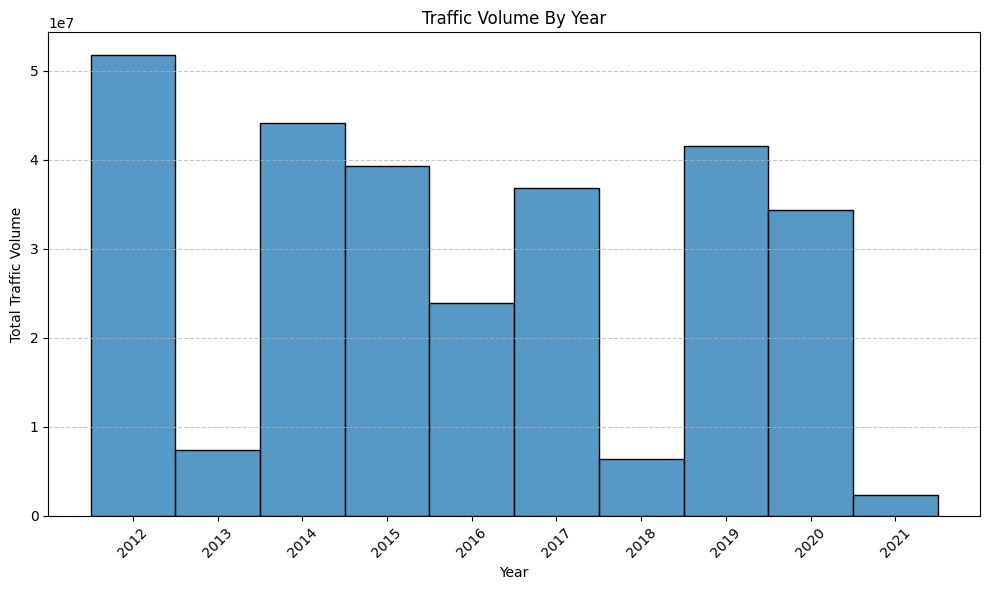

In [22]:
# Histogram for yearly traffic counts
# Convert hourly columns to numeric, coercing errors to NaN
for col in hourly_columns :
    data1[col] = pd.to_numeric(data1[col], errors='coerce')
# New column for data
data1['Daily_Traffic_Sum'] = data1[hourly_columns].sum(axis=1)
# To year objects
data1['Year'] = pd.to_datetime(data1['Date']).dt.year
# Get years
years = data1['Year'].unique()
# Link traffic sums by year
yearly_traffic_summary = data1.groupby('Year')['Daily_Traffic_Sum'].sum().reset_index()
# Histogram of total traffic counts per year
plt.figure(figsize=(10, 6))
sns.histplot(data=yearly_traffic_summary, x='Year', weights='Daily_Traffic_Sum',bins=len(yearly_traffic_summary), discrete=True, shrink=1)
plt.title('Traffic Volume By Year')
plt.xlabel('Year')
plt.ylabel('Total Traffic Volume')
plt.xticks(yearly_traffic_summary['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

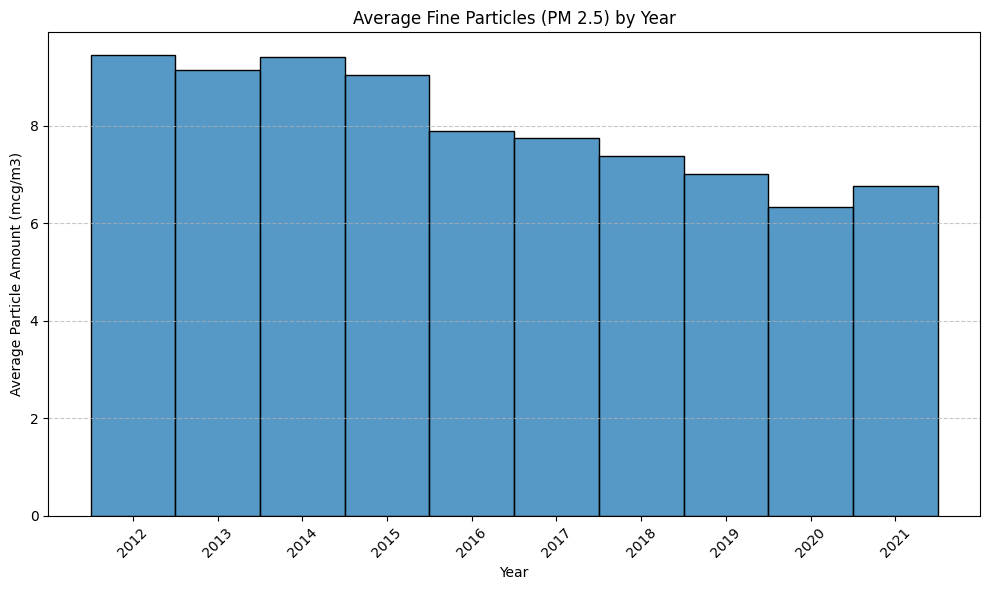

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Fine particles histogram
# Temporarily reload data2 to ensure unscaled 'Data Value' for aggregation
temp_data2 = pd.read_csv("/content/sample_data/Air_Quality_and_Health_Impacts_20260503.csv")
temp_data2.drop(columns=['Message'], inplace=True)
temp_data2 = temp_data2[(temp_data2['Name'] == 'Fine particles (PM 2.5)') | (temp_data2['Name'] == 'Nitrogen dioxide (NO2)')]
temp_data2 = temp_data2[temp_data2['Time Period'].str.startswith('Annual Average')]
temp_data2['Year'] = temp_data2['Time Period'].str.slice(-4).astype(int)
temp_data2 = temp_data2[temp_data2['Year'].between(min_year, max_year)]

particles = temp_data2[temp_data2['Name'] == 'Fine particles (PM 2.5)']
particles_yearly = particles.groupby('Year')['Data Value'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.histplot(data=particles_yearly, x='Year', weights='Data Value', bins=len(particles_yearly), discrete=True, shrink=1)
plt.title('Average Fine Particles (PM 2.5) by Year')
plt.xlabel('Year')
plt.ylabel('Average Particle Amount (mcg/m3)')
plt.xticks(particles_yearly['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

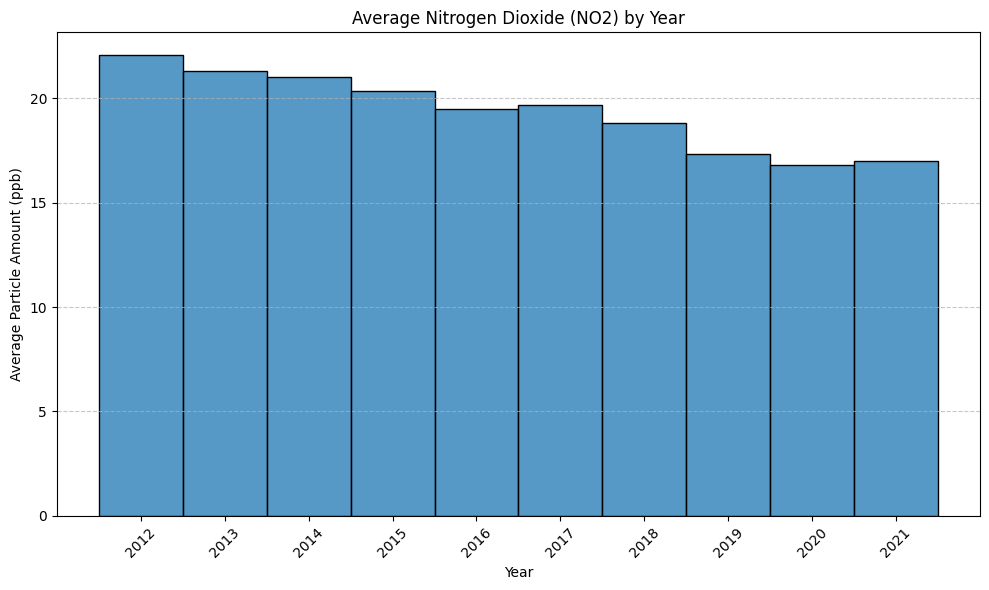

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NO2 histogram
# Temporarily reload data2 to ensure unscaled 'Data Value' for aggregation
temp_data2 = pd.read_csv("/content/sample_data/Air_Quality_and_Health_Impacts_20260503.csv")
temp_data2.drop(columns=['Message'], inplace=True)
temp_data2 = temp_data2[(temp_data2['Name'] == 'Fine particles (PM 2.5)') | (temp_data2['Name'] == 'Nitrogen dioxide (NO2)')]
temp_data2 = temp_data2[temp_data2['Time Period'].str.startswith('Annual Average')]
temp_data2['Year'] = temp_data2['Time Period'].str.slice(-4).astype(int)
temp_data2 = temp_data2[temp_data2['Year'].between(min_year, max_year)]

no2 = temp_data2[temp_data2['Name'] == 'Nitrogen dioxide (NO2)']
no2_yearly = no2.groupby('Year')['Data Value'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.histplot(data=no2_yearly, x='Year', weights='Data Value', bins=len(no2_yearly), discrete=True, shrink=1)
plt.title('Average Nitrogen Dioxide (NO2) by Year')
plt.xlabel('Year')
plt.ylabel('Average Particle Amount (ppb)')
plt.xticks(no2_yearly['Year'], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [25]:
scaler = MinMaxScaler()
columnsToScale = data1.select_dtypes(include=["number"]).columns.tolist()
scaled = scaler.fit_transform(data1[columnsToScale])
data1[columnsToScale] = pd.DataFrame(scaled)
columnsToScale = data2.select_dtypes(include=["number"]).columns.tolist()
scaled = scaler.fit_transform(data2[columnsToScale])
data2[columnsToScale] = pd.DataFrame(scaled)


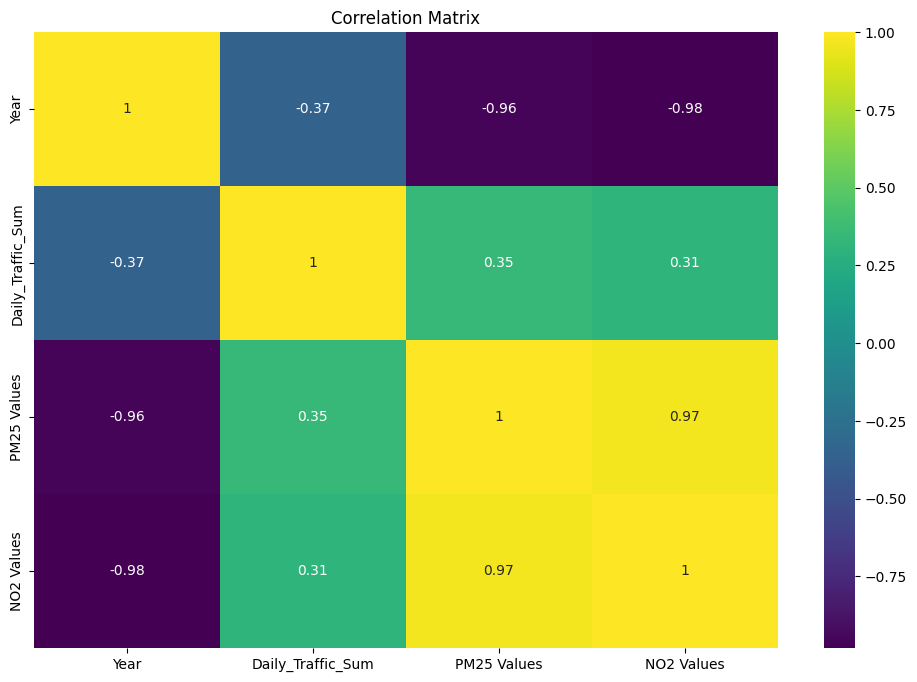

In [27]:
# Correlation Matrix (Heatmap)
#I used an article for this part
particles_values = particles_yearly.rename(columns={'Data Value': 'PM25 Values'})
no2_renamed = no2_yearly.rename(columns={'Data Value': 'NO2 Values'})

merged_data = pd.merge(yearly_traffic_summary, particles_values, on='Year', how='inner')

merged_data = pd.merge(merged_data, no2_renamed, on='Year', how='inner')

numeric_cols = merged_data.select_dtypes(include=[np.number]).columns
correlation_matrix = merged_data[numeric_cols].corr()

plt.figure(figsize=[12,8])
sns.heatmap(correlation_matrix, annot=True, cmap='viridis')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Bivariate Analysis

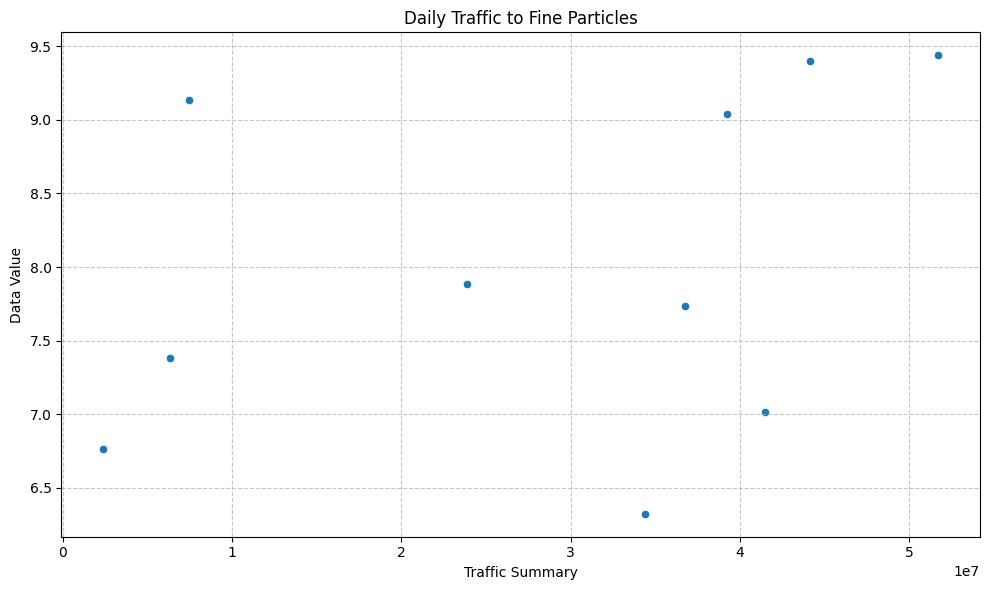

In [28]:
traffic_to_fp = pd.merge(yearly_traffic_summary, particles_yearly, on='Year')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=traffic_to_fp, x='Daily_Traffic_Sum',y='Data Value')
plt.title('Daily Traffic to Fine Particles')
plt.xlabel('Traffic Summary')
plt.ylabel('Data Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

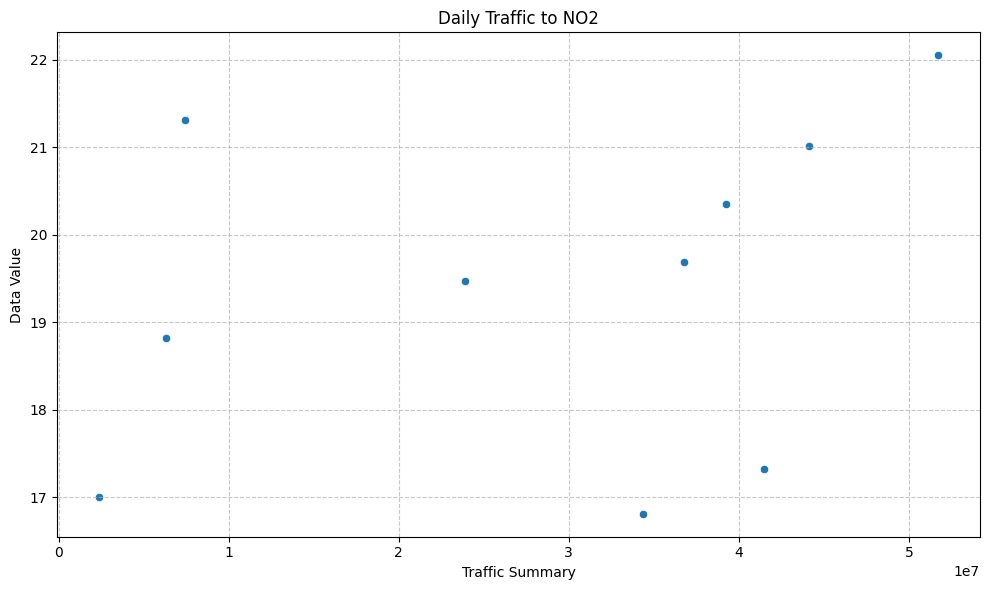

In [29]:
# scatterplot 2 (traffic_to_NO2)
traffic_to_NO2 = pd.merge(yearly_traffic_summary, no2_yearly, on='Year')
plt.figure(figsize=(10, 6))
sns.scatterplot(data=traffic_to_NO2, x='Daily_Traffic_Sum',y='Data Value')
plt.title('Daily Traffic to NO2')
plt.xlabel('Traffic Summary')
plt.ylabel('Data Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

2. Hypothesis Testing (The Statistical Proof)

Before you build a complex model, you must statistically validate your initial assumptions from Milestone 1.

    Requirement: Perform at least one formal statistical test (e.g., T-Test, ANOVA, or Chi-Square).

    Reporting: You must clearly state your p-value.

        If p < 0.05, you reject the Null Hypothesis (H0). Explain what this means in the context of your urban problem (e.g., "There is a statistically significant difference in traffic wait times between Monday and Friday").


In [ ]:
# Hypothesis testing (must have p-values)

In [30]:
from scipy.stats import pearsonr

# Pearson correlation between Daily Traffic Sum and NO2
corr_no2, p_value_no2 = pearsonr(merged_data['Daily_Traffic_Sum'], merged_data['NO2 Values'])
print(f"Pearson Correlation between Daily Traffic Sum and NO2: {corr_no2:.4f}")
print(f"P-value: {p_value_no2:.4f}")


if p_value_no2 < 0.05:
   print("The p-value for NO2 is less than 0.05, so we reject the null hypothesis.")
else:
   print("The p-value for NO2 is greater than or equal to 0.05, we fail to reject the null hypothesis.")

Pearson Correlation between Daily Traffic Sum and NO2: 0.3098
P-value: 0.3838
The p-value for NO2 is greater than or equal to 0.05, we fail to reject the null hypothesis.


In [31]:
from scipy.stats import pearsonr

# Pearson correlation between Daily Traffic Sum and PM2.5
corr_pm25, p_value_pm25 = pearsonr(merged_data['Daily_Traffic_Sum'], merged_data['PM25 Values'])
print(f"Pearson Correlation between Daily Traffic Sum and PM2.5: {corr_pm25:.4f}")
print(f"P-value: {p_value_pm25:.4f}")

if p_value_pm25 < 0.05:
   print("The p-value for PM2.5 is less than 0.05, so we reject the null hypothesis.")
else:
   print("The p-value for PM2.5 is greater than or equal to 0.05, we fail to reject the null hypothesis.")

Pearson Correlation between Daily Traffic Sum and PM2.5: 0.3471
P-value: 0.3258
The p-value for PM2.5 is greater than or equal to 0.05, we fail to reject the null hypothesis.


3. Model Building (The Engine)

Depending on your project's goal, you will implement one of the following:

    Supervised Learning: If you are predicting a specific value (Regression) or a category (Classification).

        Example: Predicting "Air Quality Index" based on traffic and weather data.

    Unsupervised Learning: If you are looking for hidden patterns or groupings.

        Example: Clustering neighborhoods into "Safety Zones" based on lighting, police presence, and emergency response times.


Text(0.5, 1.0, 'Average Fine Particles (PM 2.5) by Daily Traffic')

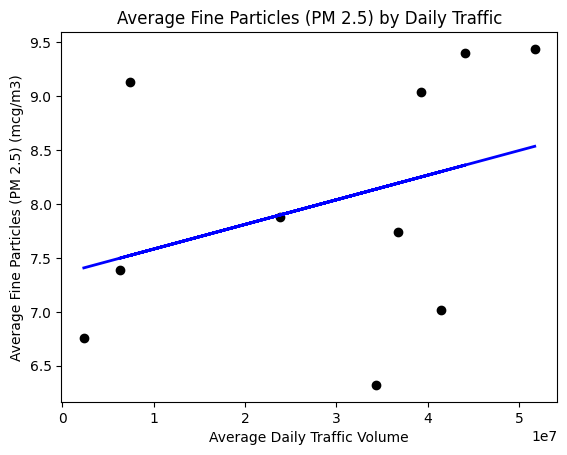

In [32]:
x = yearly_traffic_summary['Daily_Traffic_Sum'].values.reshape(-1, 1)
particles_y = particles_yearly['Data Value'].values

particles_lin_model = LinearRegression()
particles_lin_model.fit(x, particles_y)
particles_y_pred = particles_lin_model.predict(x)

plt.scatter(x, particles_y, color="black")
plt.plot(x, particles_y_pred, color="blue", linewidth=2)
plt.xlabel('Average Daily Traffic Volume')
plt.ylabel('Average Fine Particles (PM 2.5) (mcg/m3)')
plt.title("Average Fine Particles (PM 2.5) by Daily Traffic")


Text(0.5, 1.0, 'Average Nitrogen Dioxide (NO2) by Daily Traffic')

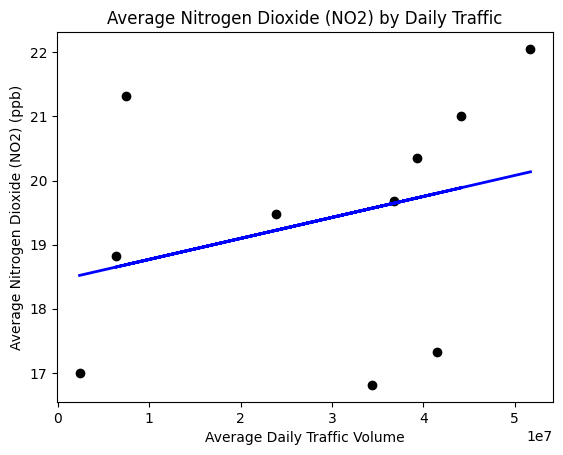

In [33]:
no2_y = no2_yearly['Data Value'].values

no2_lin_model = LinearRegression()
no2_lin_model.fit(x, no2_y)
no2_y_pred = no2_lin_model.predict(x)

plt.scatter(x, no2_y, color="black")
plt.plot(x, no2_y_pred, color="blue", linewidth=2)
plt.xlabel('Average Daily Traffic Volume')
plt.ylabel('Average Nitrogen Dioxide (NO2) (ppb)')
plt.title("Average Nitrogen Dioxide (NO2) by Daily Traffic")

4. Knowledge Discovery (The "Aha!" Moment)

This is the most important part of your report. What did you learn that wasn't obvious?

    Did your model find a feature that was way more important than you expected?

    Did your hypothesis test disprove a common urban myth?

    What is your Actionable Insight? (e.g., "The city should prioritize bike lane expansion in Zone B because...")


Results of our work and what was learned:

The Docker Challenge (Bonus Reward - 10% extra)

---

Data science is only useful if it is reproducible. We are offering a 10% bonus to teams that successfully "containerize" their project.

To earn the reward, your GitHub must include:

    A Dockerfile: This should set up the Python environment and install all necessary libraries (pandas, scikit-learn, matplotlib, etc.).

    A requirements.txt file: Listing all dependencies.

    The Result: When the container runs, it should execute a script that generates your final visualizations and saves them to an /output folder.

    Why do this? Being able to say "It works on my machine and in a container" is a high-demand skill in the current job market.
